# Notebook 02 — GAD Simulation & Training

**Kernel:** deep hedging environment (Python 3.11+, torch)

**Prerequisites:** Run `01_gad_calibration.ipynb` first — this notebook loads
`data/gad_params_fix.json` written by Notebook 01.

Steps:
1. Load calibrated GAD parameters
2. Simulate training, validation, and synthetic test paths
3. Hyperparameter search (α_bal, δ) on the synthetic validation set
4. Train Clean hedger (entropic OCE, 700 clean epochs)
5. Train Adversarial hedger (300 clean + 400 adversarial epochs, best HPs)
6. Train BS deep hedger baseline
7. Save all models to `results/real_data/`

In [1]:
import sys
import json
import time
from functools import partial
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

# ── Project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR    = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results" / "real_data"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")

Project root: /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness
Results dir:  /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data


In [2]:
from src.gad_simulator import GADParams, GADSimulator
from src.hedging.hedge_network import HedgeNet
from src.hedging.loss import EntropicOCELoss
from src.hedging.gad_adv_trainer import (
    gad_linf_attack,
    train_adv_gad,
    compute_errors,
)
from src.gbm_simulator import GBMParams, GBMPathGenerator
from src.real_data.sp500_loader import compute_entropic_risk

def _auto_device() -> torch.device:
    if torch.cuda.is_available():   return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

DEVICE = _auto_device()
print(f"Device: {DEVICE}")

Device: mps


## 1. Load Calibrated GAD Parameters

In [3]:
params_path = DATA_DIR / "gad_params_fix.json"
assert params_path.exists(), f"Run Notebook 01 first — {params_path} not found."

with open(params_path) as f:
    p_dict = json.load(f)

# Override M for training set size
M_TRAIN = 100_000
M_VAL   = 10_000
M_TEST  = 100_000
N_STEPS = 30
T       = 30 / 252
S0      = 10.0
K       = 10.0      # ATM strike = S0

params_train = GADParams(
    b0=p_dict["b0"], b1=p_dict["b1"],
    a0=p_dict["a0"], a1=p_dict["a1"],
    S0=S0, T=T, N=N_STEPS, M=M_TRAIN,
)

# Implied effective volatility at S0
SIGMA_EFF = params_train.a0 + params_train.a1 * S0

print("GAD FIX parameters:")
for k in ("b0", "b1", "a0", "a1"):
    print(f"  {k} = {p_dict[k]:.6f}")
print(f"\nImplied σ_eff (at S0={S0}): {SIGMA_EFF:.4f}")

GAD FIX parameters:
  b0 = 41.852244
  b1 = -3.765770
  a0 = 0.524758
  a1 = 0.046183

Implied σ_eff (at S0=10.0): 0.9866


## 2. Simulate Paths

In [4]:
print("Simulating training paths …")
t0 = time.perf_counter()
S_tr = GADSimulator(params_train).simulate(seed=19)
print(f"  Training: {S_tr.shape}  ({time.perf_counter()-t0:.1f}s)")

params_val  = GADParams(**{**p_dict, "M": M_VAL,  "S0": S0, "T": T, "N": N_STEPS})
params_test = GADParams(**{**p_dict, "M": M_TEST, "S0": S0, "T": T, "N": N_STEPS})

t0 = time.perf_counter()
S_val  = GADSimulator(params_val).simulate(seed=7)
S_test = GADSimulator(params_test).simulate(seed=42)
print(f"  Validation: {S_val.shape}  Test: {S_test.shape}  ({time.perf_counter()-t0:.1f}s)")

Simulating training paths …
  Training: torch.Size([100000, 31])  (0.1s)
  Validation: torch.Size([10000, 31])  Test: torch.Size([100000, 31])  (0.1s)


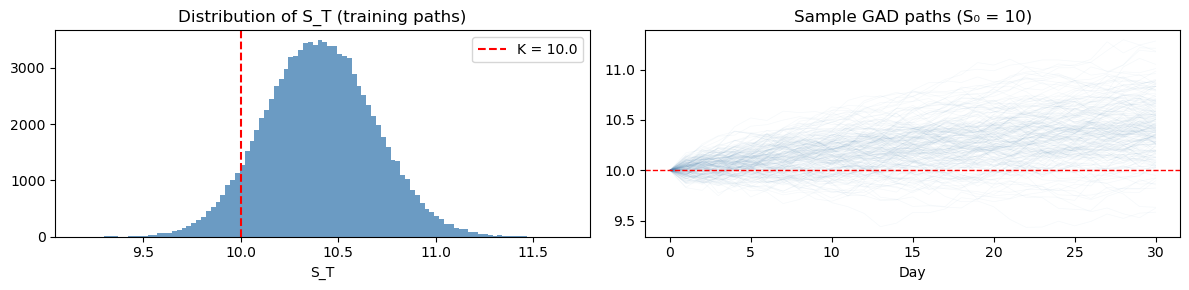

In [5]:
# Quick visual: distribution of S_T for training set
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

S_T = S_tr[:, -1].numpy()
axes[0].hist(S_T, bins=100, color="steelblue", edgecolor="none", alpha=0.8)
axes[0].axvline(K, color="red", linestyle="--", label=f"K = {K}")
axes[0].set_title("Distribution of S_T (training paths)")
axes[0].set_xlabel("S_T")
axes[0].legend()

for _ in range(200):
    idx = np.random.randint(0, M_TRAIN)
    axes[1].plot(S_tr[idx].numpy(), alpha=0.05, linewidth=0.5, color="steelblue")
axes[1].axhline(K, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Sample GAD paths (S₀ = 10)")
axes[1].set_xlabel("Day")
plt.tight_layout()
plt.show()

## 3. Loss Function & p0 Initialisation

In [6]:
LAMB = 1.0

loss_fn = EntropicOCELoss(K=K, sigma=SIGMA_EFF, T=T, lamb=LAMB, X_max=True)

# p0 initialisation: Black-Scholes ATM call price at σ_eff
p0_init = float(loss_fn.bs_price(torch.tensor(S0)).item())
print(f"BS call price (p0 init): {p0_init:.5f}")
print(f"  K={K}, S0={S0}, σ_eff={SIGMA_EFF:.4f}, T={T:.4f}")

BS call price (p0 init): 1.35149
  K=10.0, S0=10.0, σ_eff=0.9866, T=0.1190


## 4. Hyperparameter Search (on Synthetic Validation Set)

Grid search over (α_bal, δ) using a fast 50-epoch proxy. All search is done on
synthetic validation paths — the real test set is never touched.

In [7]:
ALPHA_BAL_GRID = [0.0, 1.0, 10.0]
DELTA_GRID     = [0.001, 0.003, 0.005, 0.01, 0.03, 0.05, 0.1]
HP_PROXY_EPOCHS = 50   # fast proxy; increase to 100 for more accurate search

S_tr_dev  = S_tr.to(DEVICE)
S_val_dev = S_val.to(DEVICE)

best_risk  = float("inf")
best_alpha = ALPHA_BAL_GRID[1]
best_delta = DELTA_GRID[3]
hp_results = {}

print(f"Hyperparameter search: {len(ALPHA_BAL_GRID)} × {len(DELTA_GRID)} = {len(ALPHA_BAL_GRID)*len(DELTA_GRID)} combos, {HP_PROXY_EPOCHS} proxy epochs each")

for alpha_bal in ALPHA_BAL_GRID:
    for delta in DELTA_GRID:
        attack_fn = partial(
            gad_linf_attack,
            loss_fn=loss_fn,
            delta=delta,
            iters=5,   # fewer iters for speed during HP search
        )
        net, p0 = train_adv_gad(
            S_tr_dev,
            attack_fn=attack_fn,
            loss_fn=loss_fn,
            n_clean=HP_PROXY_EPOCHS,
            n_adv=0,       # all proxy epochs are clean pre-training
            batch_size=10_000,
            lr=5e-3,
            alpha_bal=alpha_bal,
            p0_init=p0_init,
            device=DEVICE,
            desc=f"hp α={alpha_bal} δ={delta}",
        )
        errors = compute_errors(net, S_val, K, DEVICE)
        risk   = compute_entropic_risk(errors, lamb=LAMB)
        hp_results[(alpha_bal, delta)] = risk
        print(f"  α={alpha_bal:4.1f}  δ={delta:.3f}  → entropic risk = {risk:.5f}")

        if risk < best_risk:
            best_risk  = risk
            best_alpha = alpha_bal
            best_delta = delta

print(f"\nBest: α_bal={best_alpha}, δ={best_delta}  (risk={best_risk:.5f})")

# Save best HPs
with open(RESULTS_DIR / "best_hps.json", "w") as f:
    json.dump({"alpha_bal": best_alpha, "delta": best_delta, "risk": best_risk}, f, indent=2)
print(f"Saved best HPs → {RESULTS_DIR / 'best_hps.json'}")

Hyperparameter search: 3 × 7 = 21 combos, 50 proxy epochs each


hp α=0.0 δ=0.001:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

  α= 0.0  δ=0.001  → entropic risk = 0.03306


hp α=0.0 δ=0.003:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

  α= 0.0  δ=0.003  → entropic risk = 0.01757


...

  α=10.0  δ=0.030  → entropic risk = 0.00312


hp α=10.0 δ=0.05:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

  α=10.0  δ=0.050  → entropic risk = -0.05149


hp α=10.0 δ=0.1:   0%|          | 0/50 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

  α=10.0  δ=0.100  → entropic risk = 0.01950

Best: α_bal=10.0, δ=0.05  (risk=-0.05149)
Saved best HPs → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/best_hps.json


## 5. Train Clean Hedger (700 epochs)

In [8]:
N_CLEAN_ONLY = 700
BATCH_SIZE   = 10_000
LR           = 5e-3

print("Training Clean hedger …")
t0 = time.perf_counter()
net_clean, p0_clean = train_adv_gad(
    S_tr_dev,
    attack_fn=None,
    loss_fn=loss_fn,
    n_clean=N_CLEAN_ONLY,
    n_adv=0,
    batch_size=BATCH_SIZE,
    lr=LR,
    alpha_bal=1.0,
    p0_init=p0_init,
    device=DEVICE,
    desc="Clean",
)
print(f"Done in {time.perf_counter()-t0:.0f}s  p0={p0_clean:.5f}")

torch.save(net_clean.state_dict(), RESULTS_DIR / "clean_net.pt")
torch.save(torch.tensor(p0_clean), RESULTS_DIR / "clean_p0.pt")
print(f"Saved → {RESULTS_DIR}/clean_net.pt")

Training Clean hedger …


Clean:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

Done in 72s  p0=0.18131
Saved → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/clean_net.pt


## 6. Train Adversarial Hedger (300 clean + 400 adversarial epochs)

In [9]:
N_CLEAN_PRETRAIN = 300
N_ADV            = 400
ATK_ITERS        = 20    # WBPGD iterations per training step

# Load best HPs (or use defaults if HP search was skipped)
hp_path = RESULTS_DIR / "best_hps.json"
if hp_path.exists():
    with open(hp_path) as f:
        best_hps = json.load(f)
    best_alpha = best_hps["alpha_bal"]
    best_delta = best_hps["delta"]
print(f"Using α_bal={best_alpha}, δ={best_delta}")

adv_attack_fn = partial(
    gad_linf_attack,
    loss_fn=loss_fn,
    delta=best_delta,
    iters=ATK_ITERS,
)

print("Training Adversarial hedger …")
t0 = time.perf_counter()
net_adv, p0_adv = train_adv_gad(
    S_tr_dev,
    attack_fn=adv_attack_fn,
    loss_fn=loss_fn,
    n_clean=N_CLEAN_PRETRAIN,
    n_adv=N_ADV,
    batch_size=BATCH_SIZE,
    lr=LR,
    alpha_bal=best_alpha,
    p0_init=p0_init,
    device=DEVICE,
    desc="Adversarial",
)
print(f"Done in {time.perf_counter()-t0:.0f}s  p0={p0_adv:.5f}")

torch.save(net_adv.state_dict(), RESULTS_DIR / "adv_net.pt")
torch.save(torch.tensor(p0_adv), RESULTS_DIR / "adv_p0.pt")
print(f"Saved → {RESULTS_DIR}/adv_net.pt")

Using α_bal=10.0, δ=0.05
Training Adversarial hedger …


Adversarial:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

Done in 389s  p0=0.07100
Saved → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/adv_net.pt


## 7. Train BS Deep Hedger Baseline

In [10]:
# BS deep hedger: same architecture, trained on GBM paths with σ = σ_eff
bs_params = GBMParams(S0=S0, mu=0.0, sigma=SIGMA_EFF, T=T, N=N_STEPS, M=M_TRAIN)
S_bs = GBMPathGenerator(bs_params)(seed=19).to(DEVICE)
print(f"BS paths: {S_bs.shape}")

print("Training BS Deep Hedger …")
t0 = time.perf_counter()
net_bs, p0_bs = train_adv_gad(
    S_bs,
    attack_fn=None,
    loss_fn=loss_fn,
    n_clean=N_CLEAN_ONLY,
    n_adv=0,
    batch_size=BATCH_SIZE,
    lr=LR,
    alpha_bal=1.0,
    p0_init=p0_init,
    device=DEVICE,
    desc="BS-Deep",
)
print(f"Done in {time.perf_counter()-t0:.0f}s  p0={p0_bs:.5f}")

torch.save(net_bs.state_dict(), RESULTS_DIR / "bs_deep_net.pt")
torch.save(torch.tensor(p0_bs), RESULTS_DIR / "bs_deep_p0.pt")
print(f"Saved → {RESULTS_DIR}/bs_deep_net.pt")

BS paths: torch.Size([100000, 31])
Training BS Deep Hedger …


BS-Deep:   0%|          | 0/700 [00:00<?]  lc=0.0000  la=0.0000  p0=1.3515

Done in 73s  p0=1.40445
Saved → /Users/robertorandelli/projects/Deep-Hedging-and-its-Robustness/results/real_data/bs_deep_net.pt


## 8. Synthetic In-Distribution Performance (Sanity Check)

In [11]:
S_test_dev = S_test.to(DEVICE)

errors_clean_synth = compute_errors(net_clean, S_test, K, DEVICE)
errors_adv_synth   = compute_errors(net_adv,   S_test, K, DEVICE)
errors_bs_synth    = compute_errors(net_bs,    S_test, K, DEVICE)

print("── Synthetic test set (in-distribution) ─────────────")
print(f"  Clean     entropic risk: {compute_entropic_risk(errors_clean_synth):.5f}")
print(f"  Adversarial entropic risk: {compute_entropic_risk(errors_adv_synth):.5f}")
print(f"  BS Deep   entropic risk: {compute_entropic_risk(errors_bs_synth):.5f}")
print("(Lower is better. Adversarial may be slightly worse on in-distribution data.)")

── Synthetic test set (in-distribution) ─────────────
  Clean     entropic risk: -2.11884
  Adversarial entropic risk: -1.94278
  BS Deep   entropic risk: 0.16868
(Lower is better. Adversarial may be slightly worse on in-distribution data.)


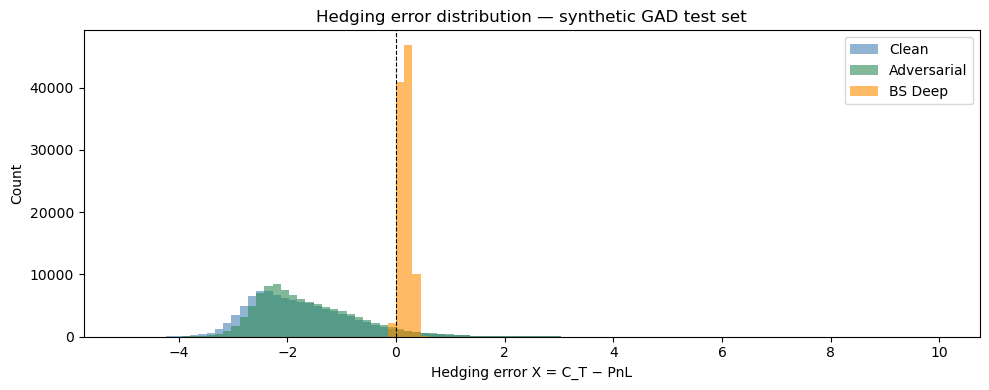

In [12]:
# Error distribution plot
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(-5, 10, 100)
ax.hist(errors_clean_synth.numpy(), bins=bins, alpha=0.6, label="Clean", color="steelblue")
ax.hist(errors_adv_synth.numpy(),   bins=bins, alpha=0.6, label="Adversarial", color="seagreen")
ax.hist(errors_bs_synth.numpy(),    bins=bins, alpha=0.6, label="BS Deep", color="darkorange")
ax.axvline(0, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("Hedging error X = C_T − PnL")
ax.set_ylabel("Count")
ax.set_title("Hedging error distribution — synthetic GAD test set")
ax.legend()
plt.tight_layout()
plt.show()

## Summary

| Model | File | Epochs |
|---|---|---|
| Clean hedger | `results/real_data/clean_net.pt` | 700 clean |
| Adversarial hedger | `results/real_data/adv_net.pt` | 300 clean + 400 adv |
| BS deep hedger | `results/real_data/bs_deep_net.pt` | 700 clean (GBM paths) |

**Next:** Run `03_gad_evaluation.ipynb` to evaluate on real S&P 500 paths.